In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

print("Loading datasets...")
installments = pd.read_csv(DATA_DIR / "HC_installments_payments.csv")
pos_cash = pd.read_csv(DATA_DIR / "HC_POS_CASH_balance.csv")
cc_balance = pd.read_csv(DATA_DIR / "HC_credit_card_balance.csv")

# Load feature engineered dataset
df = pd.read_parquet(PROCESSED_DIR / "02_feature_engineered.parquet")

print(f"installments:  {installments.shape}")
print(f"pos_cash:      {pos_cash.shape}")
print(f"cc_balance:    {cc_balance.shape}")
print(f"main df:       {df.shape}")
print("\nAll datasets loaded!")

Loading datasets...
installments:  (13605401, 8)
pos_cash:      (10001358, 8)
cc_balance:    (3840312, 23)
main df:       (307511, 173)

All datasets loaded!


In [2]:
print("=" * 50)
print("INSTALLMENT PAYMENT FEATURES")
print("=" * 50)

inst = installments.copy()

# ── Payment behavior features ────────────────────────────────
inst["PAYMENT_DIFF"] = inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]
inst["PAYMENT_RATIO"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["IS_LATE"] = (inst["DAYS_LATE"] > 0).astype(int)
inst["IS_EARLY"] = (inst["DAYS_LATE"] < 0).astype(int)
inst["UNDERPAID"] = (inst["PAYMENT_DIFF"] > 0).astype(int)

print("Aggregating 13.6M installment rows (may take ~45 secs)...")

inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_COUNT                = ("SK_ID_PREV", "count"),
    INST_LATE_COUNT           = ("IS_LATE", "sum"),
    INST_EARLY_COUNT          = ("IS_EARLY", "sum"),
    INST_UNDERPAID_COUNT      = ("UNDERPAID", "sum"),
    INST_DAYS_LATE_MEAN       = ("DAYS_LATE", "mean"),
    INST_DAYS_LATE_MAX        = ("DAYS_LATE", "max"),
    INST_DAYS_LATE_STD        = ("DAYS_LATE", "std"),
    INST_PAYMENT_RATIO_MEAN   = ("PAYMENT_RATIO", "mean"),
    INST_PAYMENT_RATIO_MIN    = ("PAYMENT_RATIO", "min"),
    INST_PAYMENT_DIFF_MEAN    = ("PAYMENT_DIFF", "mean"),
    INST_PAYMENT_DIFF_MAX     = ("PAYMENT_DIFF", "max"),
    INST_AMT_PAYMENT_SUM      = ("AMT_PAYMENT", "sum"),
    INST_AMT_INSTALMENT_SUM   = ("AMT_INSTALMENT", "sum"),
).reset_index()

# Derived ratios
inst_agg["INST_LATE_RATIO"] = (
    inst_agg["INST_LATE_COUNT"] /
    inst_agg["INST_COUNT"].replace(0, np.nan)
)
inst_agg["INST_EARLY_RATIO"] = (
    inst_agg["INST_EARLY_COUNT"] /
    inst_agg["INST_COUNT"].replace(0, np.nan)
)
inst_agg["INST_TOTAL_PAYMENT_RATIO"] = (
    inst_agg["INST_AMT_PAYMENT_SUM"] /
    inst_agg["INST_AMT_INSTALMENT_SUM"].replace(0, np.nan)
)

print(f"Installment features shape: {inst_agg.shape}")
print(f"\nLate payment stats:")
print(f"  Mean late ratio:  {inst_agg['INST_LATE_RATIO'].mean():.4f}")
print(f"  Max days late:    {inst_agg['INST_DAYS_LATE_MAX'].max():.0f}")
print(f"  Mean days late:   {inst_agg['INST_DAYS_LATE_MEAN'].mean():.2f}")

INSTALLMENT PAYMENT FEATURES
Aggregating 13.6M installment rows (may take ~45 secs)...
Installment features shape: (339587, 17)

Late payment stats:
  Mean late ratio:  0.0744
  Max days late:    2884
  Mean days late:   -11.26


In [3]:
print("=" * 50)
print("POS CASH BALANCE FEATURES")
print("=" * 50)

pos = pos_cash.copy()

# DPD status
pos["IS_DPD"] = (pos["SK_DPD"] > 0).astype(int)
pos["IS_DPD_DEF"] = (pos["SK_DPD_DEF"] > 0).astype(int)

print("Aggregating 10M POS cash rows...")

pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_COUNT              = ("SK_ID_PREV", "count"),
    POS_MONTHS_BALANCE_MEAN= ("MONTHS_BALANCE", "mean"),
    POS_MONTHS_BALANCE_MIN = ("MONTHS_BALANCE", "min"),
    POS_CNT_INSTALMENT_MEAN= ("CNT_INSTALMENT", "mean"),
    POS_CNT_INSTALMENT_MAX = ("CNT_INSTALMENT", "max"),
    POS_DPD_COUNT          = ("IS_DPD", "sum"),
    POS_DPD_DEF_COUNT      = ("IS_DPD_DEF", "sum"),
    POS_DPD_MAX            = ("SK_DPD", "max"),
    POS_DPD_MEAN           = ("SK_DPD", "mean"),
    POS_COMPLETED_COUNT    = ("NAME_CONTRACT_STATUS",
                              lambda x: (x == "Completed").sum()),
    POS_ACTIVE_COUNT       = ("NAME_CONTRACT_STATUS",
                              lambda x: (x == "Active").sum()),
).reset_index()

pos_agg["POS_DPD_RATIO"] = (
    pos_agg["POS_DPD_COUNT"] /
    pos_agg["POS_COUNT"].replace(0, np.nan)
)
pos_agg["POS_COMPLETED_RATIO"] = (
    pos_agg["POS_COMPLETED_COUNT"] /
    pos_agg["POS_COUNT"].replace(0, np.nan)
)

print(f"POS cash features shape: {pos_agg.shape}")
print(f"\nDPD stats:")
print(f"  Mean DPD ratio: {pos_agg['POS_DPD_RATIO'].mean():.4f}")
print(f"  Max DPD ever:   {pos_agg['POS_DPD_MAX'].max():.0f}")

POS CASH BALANCE FEATURES
Aggregating 10M POS cash rows...
POS cash features shape: (337252, 14)

DPD stats:
  Mean DPD ratio: 0.0210
  Max DPD ever:   4231


In [6]:
print("=" * 50)
print("CREDIT CARD BALANCE FEATURES")
print("=" * 50)

cc = cc_balance.copy()

# Utilization = balance / credit limit
cc["CC_UTILIZATION"] = (
    cc["AMT_BALANCE"] /
    cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)
cc["CC_PAYMENT_RATIO"] = (
    cc["AMT_PAYMENT_TOTAL_CURRENT"] /
    cc["AMT_TOTAL_RECEIVABLE"].replace(0, np.nan)
)
cc["CC_DRAWING_RATIO"] = (
    cc["AMT_DRAWINGS_CURRENT"] /
    cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)

print("Aggregating 3.8M credit card rows...")

cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_COUNT               = ("SK_ID_PREV", "count"),
    CC_BALANCE_MEAN        = ("AMT_BALANCE", "mean"),
    CC_BALANCE_MAX         = ("AMT_BALANCE", "max"),
    CC_UTILIZATION_MEAN    = ("CC_UTILIZATION", "mean"),
    CC_UTILIZATION_MAX     = ("CC_UTILIZATION", "max"),
    CC_DPD_COUNT           = ("SK_DPD", lambda x: (x > 0).sum()),
    CC_DPD_MAX             = ("SK_DPD", "max"),
    CC_PAYMENT_RATIO_MEAN  = ("CC_PAYMENT_RATIO", "mean"),
    CC_DRAWING_RATIO_MEAN  = ("CC_DRAWING_RATIO", "mean"),
    CC_MONTHS_BALANCE_MIN  = ("MONTHS_BALANCE", "min"),
    CC_LIMIT_MEAN          = ("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_LIMIT_MAX           = ("AMT_CREDIT_LIMIT_ACTUAL", "max"),
).reset_index()

cc_agg["CC_DPD_RATIO"] = (
    cc_agg["CC_DPD_COUNT"] /
    cc_agg["CC_COUNT"].replace(0, np.nan)
)

print(f"Credit card features shape: {cc_agg.shape}")
print(f"\nCredit utilization stats:")
print(f"  Mean utilization: {cc_agg['CC_UTILIZATION_MEAN'].mean():.4f}")
print(f"  Max utilization:  {cc_agg['CC_UTILIZATION_MAX'].max():.4f}")

CREDIT CARD BALANCE FEATURES
Aggregating 3.8M credit card rows...
Credit card features shape: (103558, 14)

Credit utilization stats:
  Mean utilization: 0.3206
  Max utilization:  11.7775


In [5]:
print(cc_balance.columns.tolist())

['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']


In [7]:
print("=" * 50)
print("MERGING ALL TIME SERIES FEATURES")
print("=" * 50)

df_final = df.copy()
print(f"Starting shape: {df_final.shape}")

# Merge installment features
df_final = df_final.merge(inst_agg, on="SK_ID_CURR", how="left")
print(f"After installments merge: {df_final.shape}")

# Merge POS cash features
df_final = df_final.merge(pos_agg, on="SK_ID_CURR", how="left")
print(f"After POS cash merge: {df_final.shape}")

# Merge credit card features
df_final = df_final.merge(cc_agg, on="SK_ID_CURR", how="left")
print(f"After credit card merge: {df_final.shape}")

print(f"\nTotal new time series features added: {df_final.shape[1] - df.shape[1]}")
print(f"Grand total features: {df_final.shape[1]}")

# Save
save_path = PROCESSED_DIR / "03_time_series_features.parquet"
df_final.to_parquet(save_path, index=False)
print(f"\nSaved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024**2:.1f} MB")

MERGING ALL TIME SERIES FEATURES
Starting shape: (307511, 173)
After installments merge: (307511, 189)
After POS cash merge: (307511, 202)
After credit card merge: (307511, 215)

Total new time series features added: 42
Grand total features: 215

Saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\data\processed\03_time_series_features.parquet
File size: 91.3 MB


TIME SERIES FEATURES — CORRELATION WITH TARGET


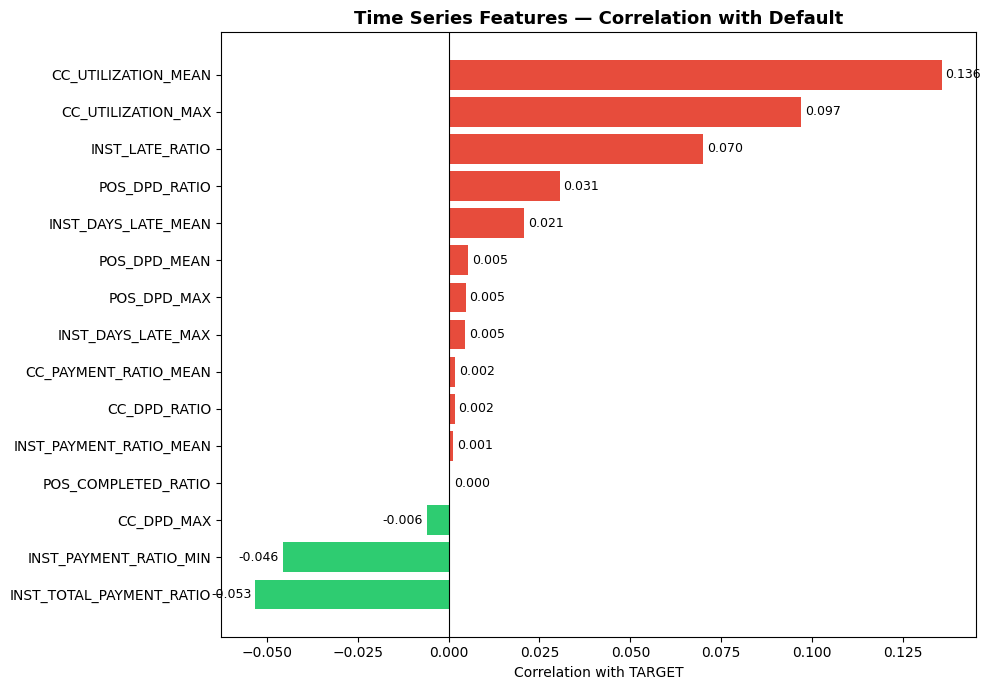


Top 5 positively correlated:
INST_DAYS_LATE_MEAN   0.0209
POS_DPD_RATIO         0.0306
INST_LATE_RATIO       0.0700
CC_UTILIZATION_MAX    0.0970
CC_UTILIZATION_MEAN   0.1356

Top 5 negatively correlated:
INST_TOTAL_PAYMENT_RATIO   -0.0531
INST_PAYMENT_RATIO_MIN     -0.0457
CC_DPD_MAX                 -0.0060
POS_COMPLETED_RATIO         0.0004
INST_PAYMENT_RATIO_MEAN     0.0014


In [8]:
print("=" * 50)
print("TIME SERIES FEATURES — CORRELATION WITH TARGET")
print("=" * 50)

ts_features = [
    "INST_LATE_RATIO", "INST_DAYS_LATE_MEAN", "INST_DAYS_LATE_MAX",
    "INST_PAYMENT_RATIO_MEAN", "INST_PAYMENT_RATIO_MIN",
    "INST_TOTAL_PAYMENT_RATIO",
    "POS_DPD_RATIO", "POS_DPD_MAX", "POS_DPD_MEAN",
    "POS_COMPLETED_RATIO",
    "CC_UTILIZATION_MEAN", "CC_UTILIZATION_MAX",
    "CC_DPD_RATIO", "CC_DPD_MAX",
    "CC_PAYMENT_RATIO_MEAN",
]

corr_ts = df_final[ts_features + ["TARGET"]].corr()["TARGET"].drop("TARGET")
corr_ts = corr_ts.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x > 0 else "#2ecc71" for x in corr_ts.values]
ax.barh(range(len(corr_ts)), corr_ts.values, color=colors)
ax.set_yticks(range(len(corr_ts)))
ax.set_yticklabels(corr_ts.index, fontsize=10)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with TARGET")
ax.set_title("Time Series Features — Correlation with Default",
             fontsize=13, fontweight="bold")

for i, val in enumerate(corr_ts.values):
    ax.text(val + (0.001 if val > 0 else -0.001), i,
            f"{val:.3f}", va="center",
            ha="left" if val > 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "08_timeseries_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 positively correlated:")
print(corr_ts.tail(5).round(4).to_string())
print("\nTop 5 negatively correlated:")
print(corr_ts.head(5).round(4).to_string())

In [9]:
print("=" * 60)
print("TIME SERIES FEATURES SUMMARY")
print("=" * 60)

print(f"""
FEATURES CREATED
----------------
Installment features:    16 features
  • INST_LATE_RATIO, INST_DAYS_LATE_MAX
  • INST_PAYMENT_RATIO_MEAN/MIN
  • INST_TOTAL_PAYMENT_RATIO

POS Cash features:       13 features
  • POS_DPD_RATIO, POS_DPD_MAX
  • POS_COMPLETED_RATIO
  • POS_MONTHS_BALANCE_MEAN

Credit Card features:    13 features
  • CC_UTILIZATION_MEAN/MAX  ← strongest signals
  • CC_DPD_RATIO, CC_DPD_MAX
  • CC_PAYMENT_RATIO_MEAN

TOTAL NEW FEATURES:      42
GRAND TOTAL FEATURES:    215

TOP TIME SERIES SIGNALS
-----------------------
1. CC_UTILIZATION_MEAN     +0.1356  ← best predictor
2. CC_UTILIZATION_MAX      +0.0970
3. INST_LATE_RATIO         +0.0700
4. POS_DPD_RATIO           +0.0306
5. INST_TOTAL_PAYMENT_RATIO -0.0531

NEXT STEP
---------
→ Handle missing values & encode categoricals
→ Cap outliers
→ Apply SMOTE
→ Save final preprocessed dataset ready for modeling
""")

df_check = pd.read_parquet(PROCESSED_DIR / "03_time_series_features.parquet")
print(f"Verified saved file: {df_check.shape}")
print("Time series feature engineering complete!")

TIME SERIES FEATURES SUMMARY

FEATURES CREATED
----------------
Installment features:    16 features
  • INST_LATE_RATIO, INST_DAYS_LATE_MAX
  • INST_PAYMENT_RATIO_MEAN/MIN
  • INST_TOTAL_PAYMENT_RATIO

POS Cash features:       13 features
  • POS_DPD_RATIO, POS_DPD_MAX
  • POS_COMPLETED_RATIO
  • POS_MONTHS_BALANCE_MEAN

Credit Card features:    13 features
  • CC_UTILIZATION_MEAN/MAX  ← strongest signals
  • CC_DPD_RATIO, CC_DPD_MAX
  • CC_PAYMENT_RATIO_MEAN

TOTAL NEW FEATURES:      42
GRAND TOTAL FEATURES:    215

TOP TIME SERIES SIGNALS
-----------------------
1. CC_UTILIZATION_MEAN     +0.1356  ← best predictor
2. CC_UTILIZATION_MAX      +0.0970
3. INST_LATE_RATIO         +0.0700
4. POS_DPD_RATIO           +0.0306
5. INST_TOTAL_PAYMENT_RATIO -0.0531

NEXT STEP
---------
→ Handle missing values & encode categoricals
→ Cap outliers
→ Apply SMOTE
→ Save final preprocessed dataset ready for modeling

Verified saved file: (307511, 215)
Time series feature engineering complete!
